In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pickle, os, warnings
warnings.filterwarnings('ignore')

from sklearn.linear_model   import LogisticRegression
from sklearn.preprocessing  import StandardScaler
from sklearn.metrics        import (
    classification_report, confusion_matrix,
    precision_recall_curve, f1_score,
    precision_score, recall_score, average_precision_score
)
import xgboost as xgb

plt.rcParams['figure.figsize'] = (13, 5)
sns.set_style('whitegrid')

# ── UPDATE THESE PATHS ────────────────────────────────────────────────────────
PARQUET_PATH = r"C:\Users\Rishit\Desktop\O2R-Order-prediction\processed\retailer_day_features.parquet"
MODEL_PATH   = r"C:\Users\Rishit\Desktop\O2R-Order-prediction\models\xgboost_order_model.pkl"
# ─────────────────────────────────────────────────────────────────────────────

os.makedirs(os.path.dirname(MODEL_PATH), exist_ok=True)
print('Setup complete.')

Setup complete.


In [2]:
print('Loading feature data...')
grid = pd.read_parquet(PARQUET_PATH)
grid['date'] = pd.to_datetime(grid['date'])
print(f'Loaded: {grid.shape}')
print(f'Date range: {grid["date"].min().date()} → {grid["date"].max().date()}')
grid.head(3)

Loading feature data...
Loaded: (1304640, 31)
Date range: 2026-01-01 → 2026-05-31


,customerId,date,ordered_today,orders_last_3_days,orders_last_7_days,orders_last_14_days,orders_last_30_days,total_orders_so_far,days_since_last_order,avg_gap_between_orders,...,is_month_start,is_month_end,hubName,shopType,retailerType,app_order_ratio,tenure_days,hubName_enc,shopType_enc,retailerType_enc
0,USR-100,2026-01-01,0,0.0,0.0,0.0,0.0,0.0,999.0,12.08,...,1,0,Crossline Events (Noida),Paan A,HVLF,0.9231,145,3,6,1
1,USR-100,2026-01-02,1,0.0,0.0,0.0,0.0,0.0,999.0,12.08,...,1,0,Crossline Events (Noida),Paan A,HVLF,0.9231,145,3,6,1
2,USR-100,2026-01-03,1,1.0,1.0,1.0,1.0,1.0,1.0,12.08,...,1,0,Crossline Events (Noida),Paan A,HVLF,0.9231,145,3,6,1


In [3]:
FEATURE_COLS = [
    'days_since_last_order',
    'avg_gap_between_orders',
    'std_gap_between_orders',
    'median_gap',
    'orders_last_3_days',
    'orders_last_7_days',
    'orders_last_14_days',
    'orders_last_30_days',
    'total_orders_so_far',
    'days_overdue',
    'is_overdue',
    'order_regularity',
    'overdue_ratio',
    'app_order_ratio',
    'tenure_days',
    'day_of_week',
    'day_of_month',
    'week_of_month',
    'month',
    'is_weekend',
    'is_month_start',
    'is_month_end',
    'hubName_enc',
    'shopType_enc',
    'retailerType_enc',
]
TARGET_COL = 'ordered_today'
print(f'Features : {len(FEATURE_COLS)}')
print(f'Target   : {TARGET_COL}')

Features : 25
Target   : ordered_today


In [4]:
EVAL_SPLIT_DATE = '2026-05-01'

train_eval = grid[grid['date'] <  EVAL_SPLIT_DATE]
val_eval   = grid[grid['date'] >= EVAL_SPLIT_DATE]

X_tr  = np.nan_to_num(train_eval[FEATURE_COLS].values, nan=0.0)
y_tr  = train_eval[TARGET_COL].values
X_val = np.nan_to_num(val_eval[FEATURE_COLS].values,   nan=0.0)
y_val = val_eval[TARGET_COL].values

neg = (y_tr == 0).sum()
pos = (y_tr == 1).sum()
scale_pos_weight = neg / pos

print(f'Train (Jan–Apr) : {len(X_tr):,} rows | positive: {y_tr.mean()*100:.1f}%')
print(f'Val   (May)     : {len(X_val):,} rows | positive: {y_val.mean()*100:.1f}%')
print(f'scale_pos_weight: {scale_pos_weight:.2f}')

Train (Jan–Apr) : 1,036,800 rows | positive: 12.9%
Val   (May)     : 267,840 rows | positive: 12.5%
scale_pos_weight: 6.77


In [5]:
print('Training Logistic Regression baseline...')
scaler = StandardScaler()
X_tr_s  = scaler.fit_transform(X_tr)
X_val_s = scaler.transform(X_val)

lr = LogisticRegression(class_weight='balanced', max_iter=500, random_state=42)
lr.fit(X_tr_s, y_tr)
lr_preds = lr.predict(X_val_s)

print('\n=== LOGISTIC REGRESSION (Validation: May 2026) ===')
print(classification_report(y_val, lr_preds, target_names=['No Order','Ordered']))

Training Logistic Regression baseline...

=== LOGISTIC REGRESSION (Validation: May 2026) ===
              precision    recall  f1-score   support

    No Order       0.96      0.78      0.86    234474
     Ordered       0.33      0.75      0.45     33366

    accuracy                           0.78    267840
   macro avg       0.64      0.76      0.66    267840
weighted avg       0.88      0.78      0.81    267840



In [6]:
print('Training Logistic Regression baseline...')

# Fill any remaining NaNs before training
import numpy as np

X_train = np.nan_to_num(X_train, nan=0.0)
X_test  = np.nan_to_num(X_test,  nan=0.0)

# LR needs scaled features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

lr = LogisticRegression(class_weight='balanced', max_iter=500, random_state=42)
lr.fit(X_train_scaled, y_train)

lr_preds = lr.predict(X_test_scaled)
lr_probs = lr.predict_proba(X_test_scaled)[:, 1]

print('\n=== LOGISTIC REGRESSION RESULTS ===')
print(classification_report(y_test, lr_preds, target_names=['No Order', 'Ordered']))

Training Logistic Regression baseline...



=== LOGISTIC REGRESSION RESULTS ===
              precision    recall  f1-score   support

    No Order       0.95      0.78      0.86    234474
     Ordered       0.32      0.74      0.45     33366

    accuracy                           0.77    267840
   macro avg       0.64      0.76      0.65    267840
weighted avg       0.88      0.77      0.81    267840



In [6]:
print('Training XGBoost for validation...')
print('(5-10 min on laptop)')

xgb_val = xgb.XGBClassifier(
    n_estimators     = 400,
    max_depth        = 5,
    learning_rate    = 0.05,
    subsample        = 0.8,
    colsample_bytree = 0.8,
    scale_pos_weight = scale_pos_weight,
    eval_metric      = 'logloss',
    random_state     = 42,
    n_jobs           = -1,
    tree_method      = 'hist'
)
xgb_val.fit(
    X_tr, y_tr,
    eval_set=[(X_val, y_val)],
    verbose=50
)
val_probs = xgb_val.predict_proba(X_val)[:, 1]
val_preds = xgb_val.predict(X_val)

print('\n=== XGBOOST VALIDATION RESULTS (May 2026) ===')
print(classification_report(y_val, val_preds, target_names=['No Order','Ordered']))

Training XGBoost for validation...
(5-10 min on laptop)
[0]	validation_0-logloss:0.67307
[50]	validation_0-logloss:0.44247
[100]	validation_0-logloss:0.42023
[150]	validation_0-logloss:0.39879
[200]	validation_0-logloss:0.38356
[250]	validation_0-logloss:0.36969
[300]	validation_0-logloss:0.36026
[350]	validation_0-logloss:0.35021
[399]	validation_0-logloss:0.34250

=== XGBOOST VALIDATION RESULTS (May 2026) ===
              precision    recall  f1-score   support

    No Order       0.96      0.85      0.90    234474
     Ordered       0.42      0.73      0.53     33366

    accuracy                           0.84    267840
   macro avg       0.69      0.79      0.72    267840
weighted avg       0.89      0.84      0.86    267840



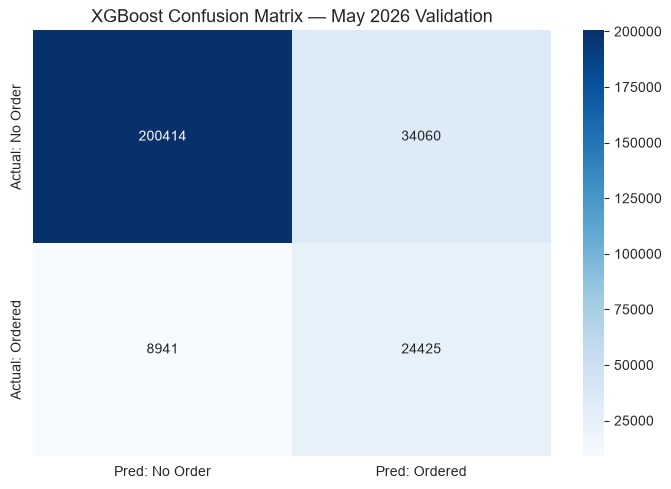

True Positives  (correct orders caught)  : 24,425
False Positives (wasted calls)           : 34,060
False Negatives (missed orders)          : 8,941
True Negatives  (correctly skipped)      : 200,414


In [7]:
# Confusion matrix
cm = confusion_matrix(y_val, val_preds)
plt.figure(figsize=(7,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Pred: No Order','Pred: Ordered'],
            yticklabels=['Actual: No Order','Actual: Ordered'])
plt.title('XGBoost Confusion Matrix — May 2026 Validation', fontsize=13)
plt.tight_layout(); plt.show()

tn, fp, fn, tp = cm.ravel()
print(f'True Positives  (correct orders caught)  : {tp:,}')
print(f'False Positives (wasted calls)           : {fp:,}')
print(f'False Negatives (missed orders)          : {fn:,}')
print(f'True Negatives  (correctly skipped)      : {tn:,}')

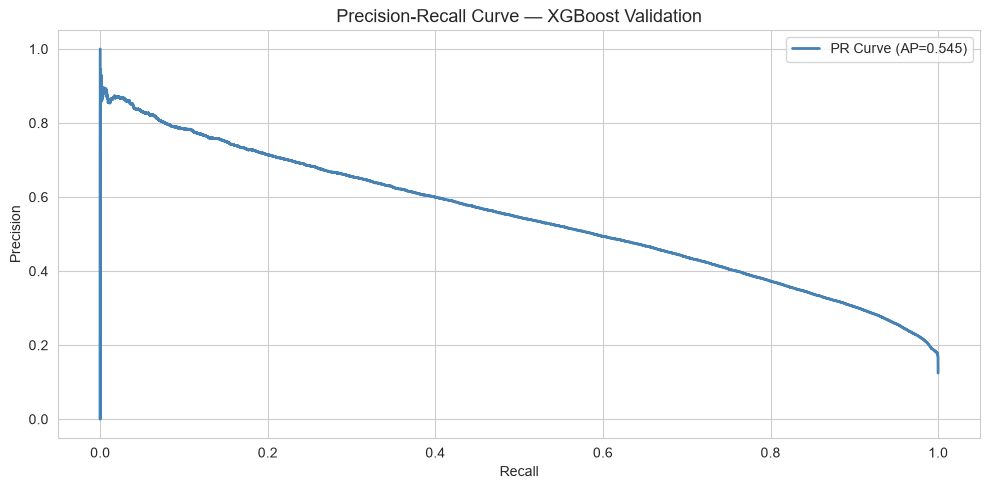

In [8]:
# Precision-Recall curve
precision, recall, _ = precision_recall_curve(y_val, val_probs)
ap = average_precision_score(y_val, val_probs)

plt.figure(figsize=(10,5))
plt.plot(recall, precision, color='steelblue', lw=2, label=f'PR Curve (AP={ap:.3f})')
plt.xlabel('Recall'); plt.ylabel('Precision')
plt.title('Precision-Recall Curve — XGBoost Validation', fontsize=13)
plt.legend(); plt.tight_layout(); plt.show()

In [9]:
total_retailers_val = val_eval['customerId'].nunique()
total_actual_orders = int(y_val.sum())

print(f'May 2026 validation: {total_retailers_val:,} retailers, {total_actual_orders:,} actual orders')
print()

rows = []
for t in [0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8]:
    p = (val_probs >= t).astype(int)
    calls     = int(p.sum())
    captured  = int(((p==1) & (y_val==1)).sum())
    missed    = total_actual_orders - captured
    prec      = precision_score(y_val, p, zero_division=0)
    rec       = recall_score(y_val, p, zero_division=0)
    f1        = f1_score(y_val, p, zero_division=0)
    reduction = (1 - calls / total_retailers_val) * 100
    rows.append({
        'Threshold'       : f'{int(t*100)}%',
        'Calls Made'      : f'{calls:,}',
        'Call Reduction'  : f'{reduction:.0f}%',
        'Orders Captured' : f'{captured:,}',
        'Orders Missed'   : f'{missed:,}',
        'Precision'       : f'{prec*100:.1f}%',
        'Recall'          : f'{rec*100:.1f}%',
        'F1'              : f'{f1:.3f}'
    })

print('=== THRESHOLD TABLE (show this to your sir) ===')
print(pd.DataFrame(rows).to_string(index=False))

May 2026 validation: 8,640 retailers, 33,366 actual orders

=== THRESHOLD TABLE (show this to your sir) ===
Threshold Calls Made Call Reduction Orders Captured Orders Missed Precision Recall    F1
      20%    122,728         -1320%          31,669         1,697     25.8%  94.9% 0.406
      30%     97,058         -1023%          29,853         3,513     30.8%  89.5% 0.458
      40%     75,859          -778%          27,316         6,050     36.0%  81.9% 0.500
      50%     58,485          -577%          24,425         8,941     41.8%  73.2% 0.532
      60%     44,054          -410%          21,077        12,289     47.8%  63.2% 0.544
      70%     31,340          -263%          16,956        16,410     54.1%  50.8% 0.524
      80%     19,580          -127%          12,127        21,239     61.9%  36.3% 0.458


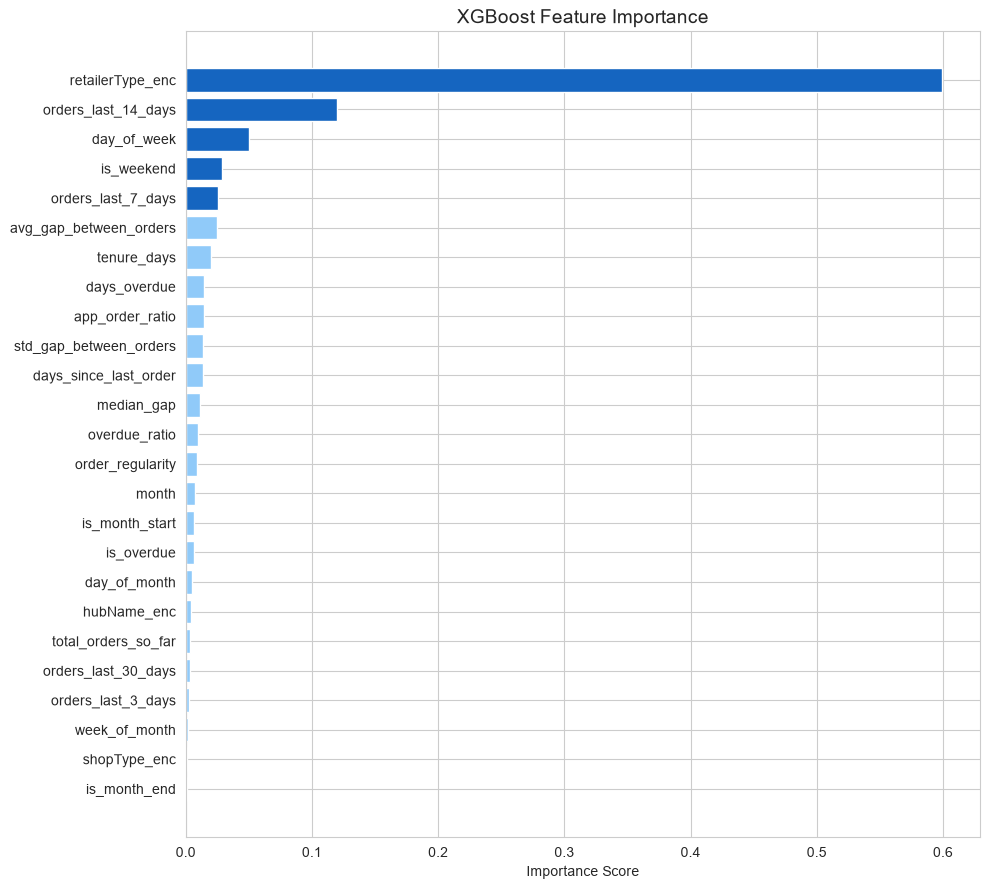

Top 5 features:
            Feature  Importance
 orders_last_7_days    0.025668
         is_weekend    0.028949
        day_of_week    0.050139
orders_last_14_days    0.120244
   retailerType_enc    0.599361


In [10]:
feat_df = pd.DataFrame({
    'Feature'    : FEATURE_COLS,
    'Importance' : xgb_val.feature_importances_
}).sort_values('Importance', ascending=True)

colors = ['#1565C0' if i >= len(feat_df)-5 else '#90CAF9'
          for i in range(len(feat_df))]

plt.figure(figsize=(10,9))
plt.barh(feat_df['Feature'], feat_df['Importance'], color=colors)
plt.title('XGBoost Feature Importance', fontsize=14)
plt.xlabel('Importance Score')
plt.tight_layout(); plt.show()

print('Top 5 features:')
print(feat_df.tail(5)[['Feature','Importance']].to_string(index=False))

In [11]:
print('Training FINAL model on full Jan–May data...')
print('(5-10 min)')

X_all = np.nan_to_num(grid[FEATURE_COLS].values, nan=0.0)
y_all = grid[TARGET_COL].values

neg_all = (y_all == 0).sum()
pos_all = (y_all == 1).sum()
spw_all = neg_all / pos_all

print(f'Full training set: {len(X_all):,} rows | scale_pos_weight: {spw_all:.2f}')

xgb_final = xgb.XGBClassifier(
    n_estimators     = 400,
    max_depth        = 5,
    learning_rate    = 0.05,
    subsample        = 0.8,
    colsample_bytree = 0.8,
    scale_pos_weight = spw_all,
    eval_metric      = 'logloss',
    random_state     = 42,
    n_jobs           = -1,
    tree_method      = 'hist'
)
xgb_final.fit(X_all, y_all, verbose=50)

print('\nFinal model training complete.')

Training FINAL model on full Jan–May data...
(5-10 min)
Full training set: 1,304,640 rows | scale_pos_weight: 6.82

Final model training complete.


In [12]:
with open(MODEL_PATH, 'wb') as f:
    pickle.dump({
        'model'        : xgb_final,
        'feature_cols' : FEATURE_COLS,
        'threshold'    : 0.4,          # default — adjust from threshold table above
        'trained_on'   : 'Jan-May 2026',
        'predicts_for' : 'June 2026'
    }, f)

print(f'Final model saved → {MODEL_PATH}')
print()
print('=== TRAINING COMPLETE ===')
print('This model is trained on Jan–May 2026 and ready to predict June 2026.')
print('\nNext → Run Notebook 4 (June Predictions)')

Final model saved → C:\Users\Rishit\Desktop\O2R-Order-prediction\models\xgboost_order_model.pkl

=== TRAINING COMPLETE ===
This model is trained on Jan–May 2026 and ready to predict June 2026.

Next → Run Notebook 4 (June Predictions)
